# PRÁCTICA: ANÁLISIS EXPLORATORIO DE DATOS
Programación de IA

En esta practica, dispondremos del dataset AB_NYC_2019 que describe la actividad de los alojamientos suscritos a la plataforma Airbnb en la ciudad de New York en el año 2019. 
La práctica consiste en realizar un análisis exploratorio de datos completos y dejar los datos "limpios" para su uso.

In [79]:
# Importación de librerías y lectura del dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset
df = pd.read_csv('AB_NYC_2019.csv') #Quitamos la columna id que se añade por defecto al cargar el dataset
# Mostrar las primeras filas del dataset
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,week_price,PETS Allowed,swimming pool
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1043,pets allowed,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,1575,yes,0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,1050,no,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,623,no,0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,560,no,1


# Grado de fiabilidad. Regla del 10
Comprobaremos que se cumpla la Regla del 10: nºfilas >= nºcolumnas*10

In [80]:
#Numero de columnas
columnas = df.drop(["id", "host_id"], axis=1).columns
print("Número de columnas:", len(columnas))

#Número de filas
filas = len(df)
print("Número de filas:", filas)

#Regla del 10
print("Límite para cumplir la regla del 10:", len(columnas)*10)
if filas > len(columnas)*10:
    print("El dataset cumple con la regla del 10.")
else:
    print("El dataset no cumple con la regla del 10.")

Número de columnas: 17
Número de filas: 48895
Límite para cumplir la regla del 10: 170
El dataset cumple con la regla del 10.


# Análisis Descriptivo

Información sobre el dataset

In [81]:
#Información del dataset, cuantos valores nulos hay, tipo de datos, etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  object 
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [82]:
# Lista de columnas
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'week_price', 'PETS Allowed', 'swimming pool'],
      dtype='object')

In [83]:
#Datos estadísticos
df.describe()

,id,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,7.028755,23.274466,1.373221,8.229001,112.931936
std,1.098311e+07,7.861097e+07,0.054530,0.046157,20.511078,44.550582,1.680442,42.656668,131.794883
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,-9.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,1250.000000,629.000000,58.500000,985.000000,564.000000


Visualizaciones gráficas para el dataset
A continuación se muestran algunos ejemplos de visualizaciones útiles para el análisis exploratorio de este dataset:

1. Histograma de precios
2. Gráfico de barras de alojamientos por barrio
3. Mapa de dispersión geográfica (latitud vs longitud)
4. Gráfico de barras por tipo de habitación

Se incluye el código para cada visualización.

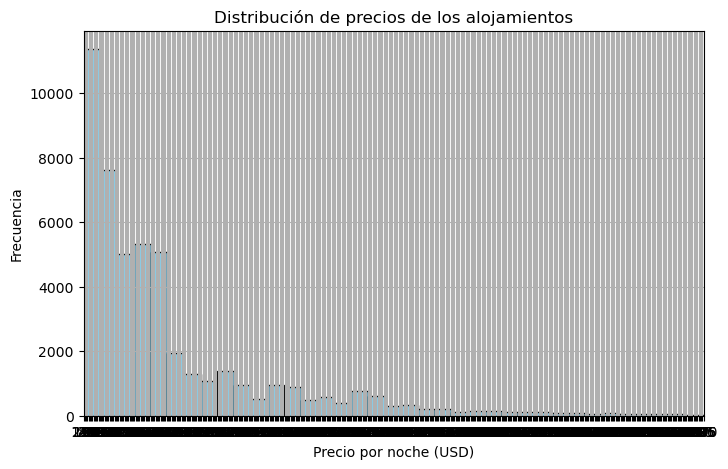

In [84]:
# 1. Histograma de precios
plt.figure(figsize=(8,5))
df['price'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de precios de los alojamientos')
plt.xlabel('Precio por noche (USD)')
plt.ylabel('Frecuencia')
plt.xlim(0, 500)
plt.show()

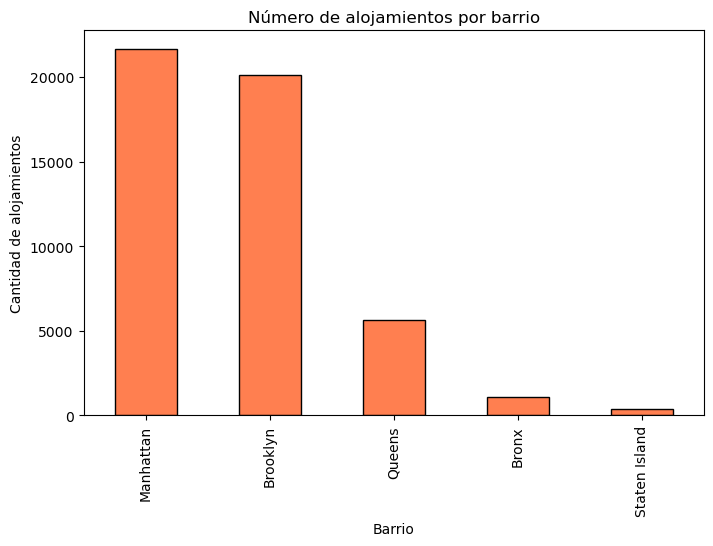

In [85]:
# 2. Gráfico de barras de alojamientos por barrio
plt.figure(figsize=(8,5))
df['neighbourhood_group'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Número de alojamientos por barrio')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de alojamientos')
plt.show()

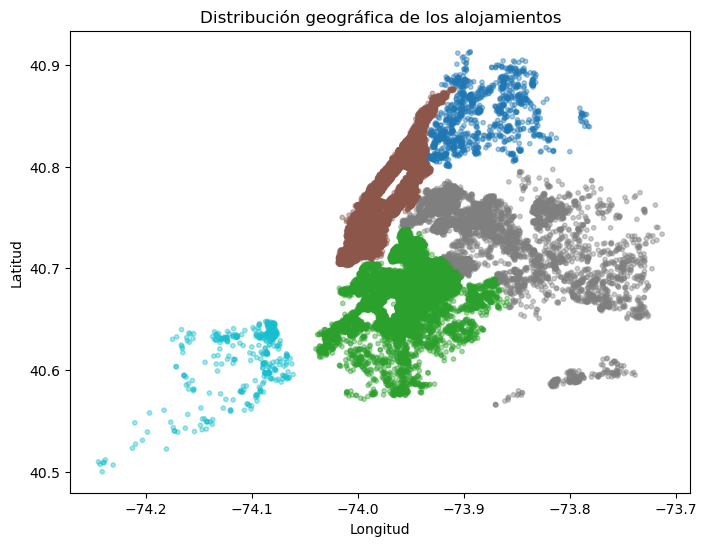

In [86]:
# 3. Mapa de dispersión geográfica de alojamientos
plt.figure(figsize=(8,6))
plt.scatter(df['longitude'], df['latitude'], c=df['neighbourhood_group'].astype('category').cat.codes, cmap='tab10', alpha=0.4, s=10)
plt.title('Distribución geográfica de los alojamientos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

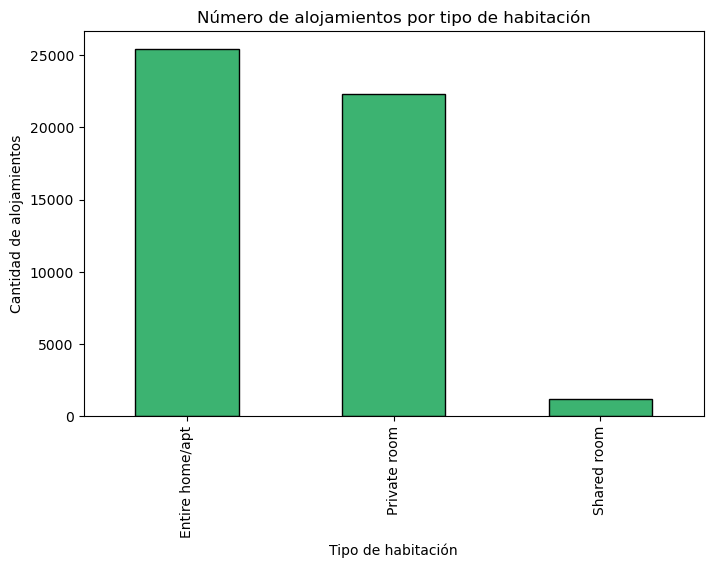

In [87]:
# 5. Gráfico de barras por tipo de habitación
plt.figure(figsize=(8,5))
df['room_type'].value_counts().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Número de alojamientos por tipo de habitación')
plt.xlabel('Tipo de habitación')
plt.ylabel('Cantidad de alojamientos')
plt.show()

## Tipos de variables

In [88]:
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,week_price,PETS Allowed,swimming pool
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1043,pets allowed,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,1575,yes,0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,1050,no,0


Tipos de cada columna. Usaremos la visualización de los 3 primeros apartamentos para comprobar que cada columna corresponde con el tipo de dato.

In [89]:
# Tipos de cada columna
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                              object
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
week_price                         object
PETS Allowed                       object
swimming pool                      object
dtype: object

Observamos que la columna "price" es de tipo object (string) pero en el dataframe son enteros, por tanto conviene realizar la transformación.

Ocurre lo mismo con la columna "week_price" y "swimming pool".

In [90]:
# Tranformamos la columna "price" y "week_price" a tipo numérico
df["price"] = pd.to_numeric(df["price"], errors='coerce') #Usamos coerce para convertir los valores no válidos a NaN
df["week_price"] = pd.to_numeric(df["week_price"], errors='coerce')
df["swimming pool"] = pd.to_numeric(df["swimming pool"], errors='coerce')

In [91]:
#Comprobamos de nuevo los tipos de cada columna
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
week_price                        float64
PETS Allowed                       object
swimming pool                     float64
dtype: object

Tratamiento de datos ausentes

In [92]:
# Comprobaremos los valores ausentes de todas las columnas
print("Valores nulos por columna:")
print(df.isnull().sum())

#Valores nulos por fila
print("\nFilas por valores nulos:")
print(df.isnull().sum(axis=1).value_counts())

Valores nulos por columna:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                               124
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
week_price                          124
PETS Allowed                          0
swimming pool                      3231
dtype: int64

Filas por valores nulos:
0    36160
2     9452
1     2576
3      689
4       17
5        1
Name: count, dtype: int64


A partir de estos datos tomaremos distintas soluciones para distintas columnas:

1. Columnas name, host_name, price y week_price: eliminaremos las FILAS, ya que es un número bastante bajo en comparación a la cantidad de filas totales que hay en el dataframe.


2. Columnas swimming pool, last_review y reviews_per_month: sustituiremos los valores NaN por otros valores válidos.


# 1. Cambio de valores

En este apartado, mapearemos valores para homogeinizar los valores de las columnas.

In [93]:
#Recorremos para ver columna por columna
for c in df.columns:
    print("-----------------")
    print(df[c].value_counts())

-----------------
id
36487245    1
2539        1
2595        1
3647        1
3831        1
           ..
7750        1
7726        1
7322        1
7097        1
6848        1
Name: count, Length: 48895, dtype: int64
-----------------
name
Hillside Hotel                                     18
Home away from home                                17
New york Multi-unit building                       16
Brooklyn Apartment                                 12
Loft Suite @ The Box House Hotel                   11
                                                   ..
Charming one bedroom - newly renovated rowhouse     1
Affordable room in Bushwick/East Williamsburg       1
Sunny Studio at Historical Neighborhood             1
43rd St. Time Square-cozy single bed                1
Room for rest                                       1
Name: count, Length: 47905, dtype: int64
-----------------
host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
            ...

# minimum_nights

Existen valores para las noches que son negativos. Vamos a proceder a cambiar los valores negativos a un mínimo de noches de 1.

In [94]:
#Comprobamos valores
df["minimum_nights"].value_counts()

minimum_nights
 1      12718
 2      11695
 3       7996
 30      3760
 4       3302
        ...  
 114        1
 85         1
 36         1
-6          1
-8          1
Name: count, Length: 116, dtype: int64

In [95]:
#Reemplazamos los valores negativos por 1
df.loc[df['minimum_nights'] < 0, 'minimum_nights'] = 1

In [96]:
#Volvemos a comprobar
df["minimum_nights"].value_counts()

minimum_nights
1      12725
2      11695
3       7996
30      3760
4       3302
       ...  
275        1
182        1
114        1
85         1
36         1
Name: count, Length: 109, dtype: int64

# PETS Allowed

Existen valores que aportan la misma información que sí o no, así que procedemos a unificarlo.

In [97]:
#Observamos los valores de la columna
df["PETS Allowed"].value_counts()

PETS Allowed
no              28581
yes              8134
pets allowed     4120
never            4047
we love pets     4013
Name: count, dtype: int64

Como podemos observar, existen más valores a parte de "yes" o "no". Vamos a convertir esos valores diferentes a uno de esos dos.

In [98]:
# SÍ permitidos
df["PETS Allowed"] = df["PETS Allowed"].replace("pets allowed", "yes")
df["PETS Allowed"] = df["PETS Allowed"].replace("we love pets", "yes")

# NO permitidos
df["PETS Allowed"] = df["PETS Allowed"].replace("never", "no")

In [99]:
#Observamos los valores de la columna para ver si se ha ejecutado correctamente
df["PETS Allowed"].value_counts()

PETS Allowed
no     32628
yes    16267
Name: count, dtype: int64

# 2. Eliminación de filas

In [100]:
#Eliminamos las filas con algún valor nulo de las columnas price, week_price, name y host_namen
df = df.dropna(subset=['price', 'week_price', 'name', 'host_name'])
#Comprobamos de nuevo los valores nulos por columna
print("\nValores nulos por columna después de eliminar filas con valores nulos:")
print(df.isnull().sum())


Valores nulos por columna después de eliminar filas con valores nulos:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10019
reviews_per_month                 10019
calculated_host_listings_count        0
availability_365                      0
week_price                            0
PETS Allowed                          0
swimming pool                      3220
dtype: int64


# Swimming Pool

A continuación, comprobaremos los valores existentes en la columna "swimming pool".

In [101]:
#Mostramos valores
print("Valores válidos en 'swimming pool': ", df["swimming pool"].value_counts())

#Mostrar valores Nan en "swimming pool"
print("Valores nulos en 'swimming pool': ", df["swimming pool"].isna().sum())

Valores válidos en 'swimming pool':  swimming pool
0.0    35744
1.0     9770
Name: count, dtype: int64
Valores nulos en 'swimming pool':  3220


Como podemos observar, obtenemos 35744 valores 0, lo cual quiere decir que el apartamento no cuenta con piscina.
Por otro lado, 9770 apartamentos que sí las tienen.

Este caso resulta muy abierto a interpretaciones, ya que contar con 3220 valores NaN no puede "no significar nada". 

¿Qué significa el NaN en esta columna? ¿Podría significar que el apartamento NO cuenta con piscina? Desde mi punto de vista, el caso más lógico sería este último: NaN no es un dato desconocido, sino que muy probablemente signifique que el apartamento no tiene piscina y es por ello mi decisión de rellenar los valores NaN con 0

In [102]:
# Relleno los valores NaN de "swimming pool" por 0
df["swimming pool"] = df["swimming pool"].fillna(0)

In [103]:
#Comprobamos
print("Valores nulos en 'swimming pool' después de rellenar con 0: ", df["swimming pool"].isna().sum())
print("Valores válidos en 'swimming pool' después de rellenar con 0: ", df["swimming pool"].value_counts())

Valores nulos en 'swimming pool' después de rellenar con 0:  0
Valores válidos en 'swimming pool' después de rellenar con 0:  swimming pool
0.0    38964
1.0     9770
Name: count, dtype: int64


# Reviews_per_month

Aquí podemos decir que existe un caso parecido. 

En una variable que recoge la cantidad de reviews por mes, si existe valores NaN, ¿es porque no hay reviews o porque no se pueden calcular?

En mi caso, los valores NaN que aparecen en esta columna se pueden interpretar como que no se ha registrado ninguna review en el mes, así que pueden rellenarse como valor 0.

In [104]:
# Vemos cuantos valores nulos hay en "reviews_per_month"
print("Valores no validos en la columna 'reviews_per_month': ", df["reviews_per_month"].isna().sum())

Valores no validos en la columna 'reviews_per_month':  10019


In [105]:
# Rellenamos valores nulos como 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [106]:
#Comprobamos de nuevo los valores nulos por columna
print("\nValores nulos por columna después de rellenar 'reviews_per_month' con 0:", df["reviews_per_month"].isna().sum())


Valores nulos por columna después de rellenar 'reviews_per_month' con 0: 0


# last_review

Para esta columna, hemos decidido eliminar esta columna, puesto que tenemos otras dos que nos aportan información relacionada ("reviews_per_month" y "numbers_of_review") y así evitamos imputar fechas.

In [107]:
#Eliminamos la columna last_review
df = df.drop("last_review", axis = 1)
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,week_price,PETS Allowed,swimming pool
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,0.21,6,365,1043.0,yes,0.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,0.38,2,355,1575.0,yes,0.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,0.00,1,365,1050.0,no,0.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,4.64,1,194,623.0,no,0.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,0.10,1,0,560.0,no,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70.0,2,0,0.00,2,9,490.0,no,0.0
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40.0,4,0,0.00,2,36,280.0,yes,0.0
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115.0,10,0,0.00,1,27,805.0,yes,1.0
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55.0,1,0,0.00,6,2,385.0,yes,0.0


# id y host_id

Borraremos estas dos columnas, puesto que son id's que se han asignado y no aportan ningún valor

In [108]:
df.drop(columns=["id", "host_id"], axis=1, inplace=True)

A continuación, revisaremos que todos los valores sean correctos.

In [109]:
# Revisión de valores anómalos y tipos de datos
print('--- Revisión de valores "?", "NA", "None", "null" o vacíos por columna ---')
for col in df.columns:
    count_q = (df[col] == '?').sum() if df[col].dtype == 'object' else 0
    count_na = (df[col] == np.nan).sum() if df[col].dtype == 'object' else 0
    count_none = (df[col] == 'None').sum() if df[col].dtype == 'object' else 0
    count_null = (df[col] == 'null').sum() if df[col].dtype == 'object' else 0
    count_empty = (df[col] == '').sum() if df[col].dtype == 'object' else 0
    if any([count_q, count_na, count_none, count_null, count_empty]):
        print(f'{col}: ?={count_q}, NA={count_na}, None={count_none}, null={count_null}, vacío={count_empty}')

print('\n--- Revisión de valores NaN por columna ---')
print(df.isnull().sum())

print('\n--- Tipos de datos de cada columna ---')
print(df.dtypes)

--- Revisión de valores "?", "NA", "None", "null" o vacíos por columna ---

--- Revisión de valores NaN por columna ---
name                              0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
week_price                        0
PETS Allowed                      0
swimming pool                     0
dtype: int64

--- Tipos de datos de cada columna ---
name                               object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64

In [110]:
print(df.dtypes)
df.head(5)

name                               object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
week_price                        float64
PETS Allowed                       object
swimming pool                     float64
dtype: object


,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,week_price,PETS Allowed,swimming pool
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,0.21,6,365,1043.0,yes,0.0
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,0.38,2,355,1575.0,yes,0.0
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,0.00,1,365,1050.0,no,0.0
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,4.64,1,194,623.0,no,0.0
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,0.10,1,0,560.0,no,1.0


# Datos Atípicos

En este apartado, trateremos los datos atípicos como valores duplicados y outliers

In [111]:
#Visualizamos filas de datos duplicados
if any(df.duplicated()):
    print("existen filas duplicadas")
else: 
    print("No existen filas duplicadas")

No existen filas duplicadas


Podemos comprobar que no existen filas duplicadas.

A continuación, usaremos boxplot para buscar outliers. Para ello, lo buscaremos en las columnas numéricas

In [112]:
# Miramos para seleccionar
df.dtypes

name                               object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
week_price                        float64
PETS Allowed                       object
swimming pool                     float64
dtype: object

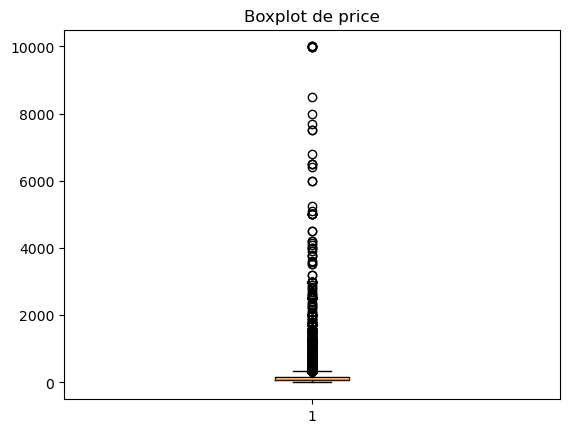

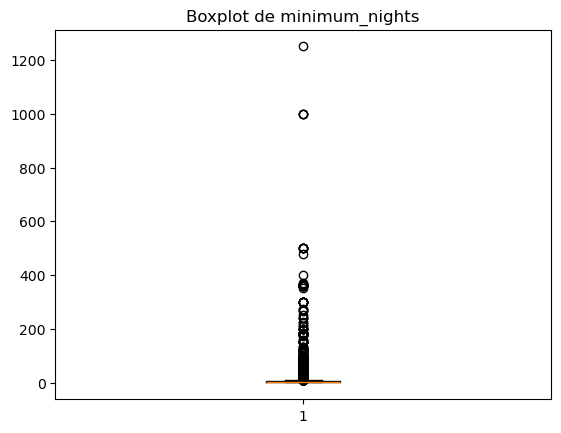

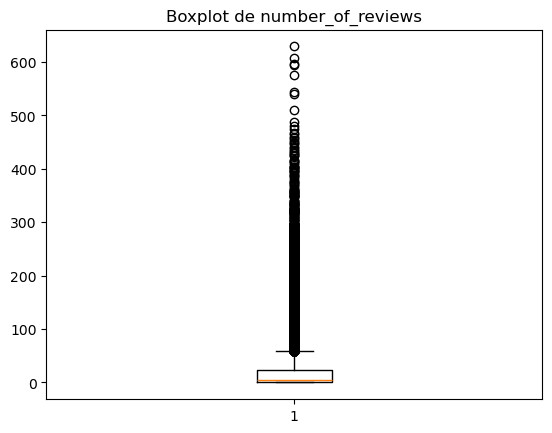

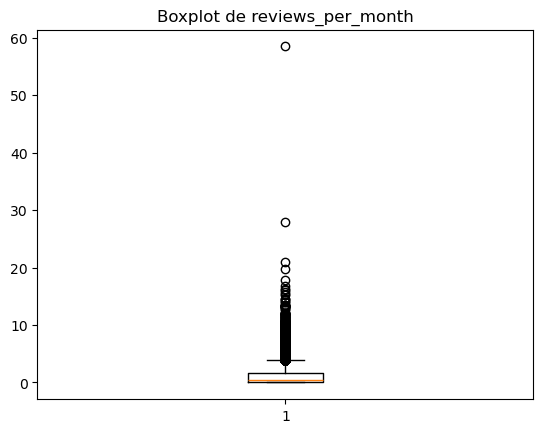

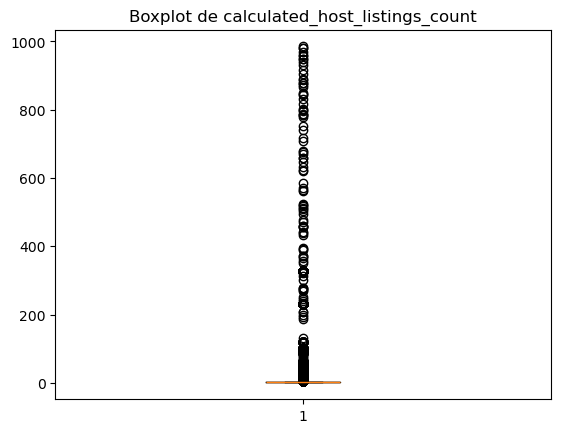

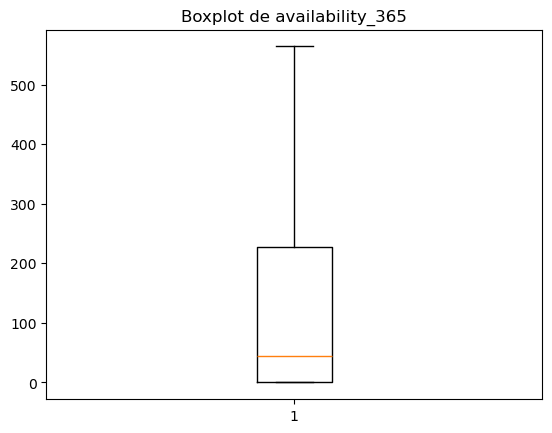

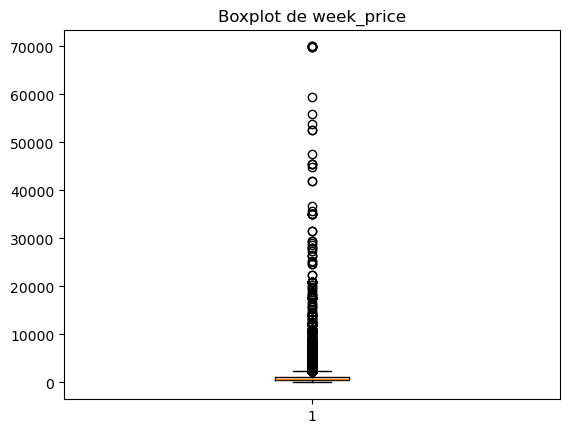

In [113]:
#Columnas numéricas. En ellas excluiremos latitud y longitud, puesto que la información que aportan son sobre localizaciones
numericas = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365", "week_price"]

#Vamos a representar los boxplots
for c in numericas:
    bp = plt.boxplot(df[c])
    
    plt.title(f"Boxplot de {c}")
    plt.show()




Como podemos observar, en todas las columnas seleccionadas existen gran número de outliers salvo en availability_365. Será excluida de la lista y los demás elementos serán tratados, recortando los outliers a valores máximos o minimos según convenga.

price -> Antes: 2965 | Después: 0


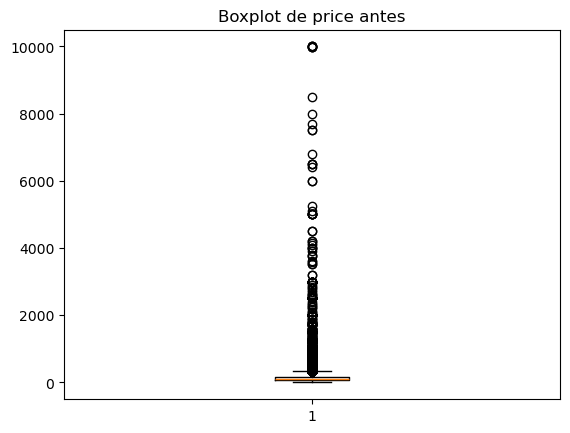

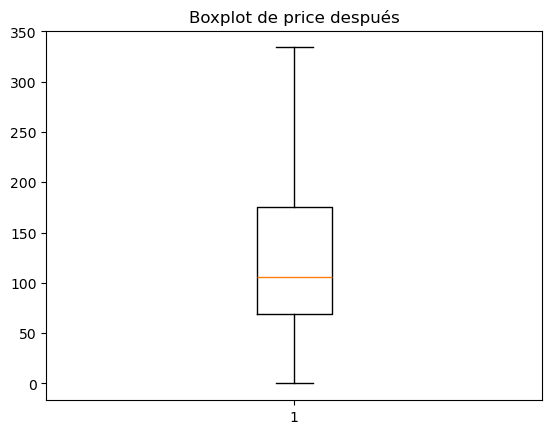

minimum_nights -> Antes: 6584 | Después: 0


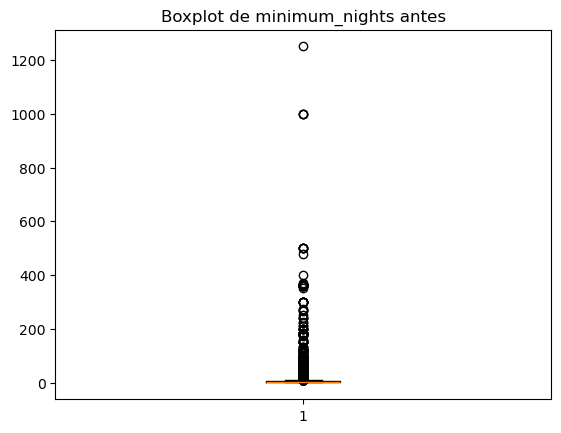

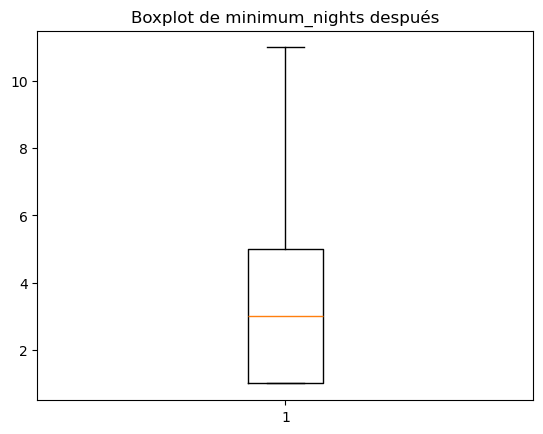

number_of_reviews -> Antes: 6003 | Después: 0


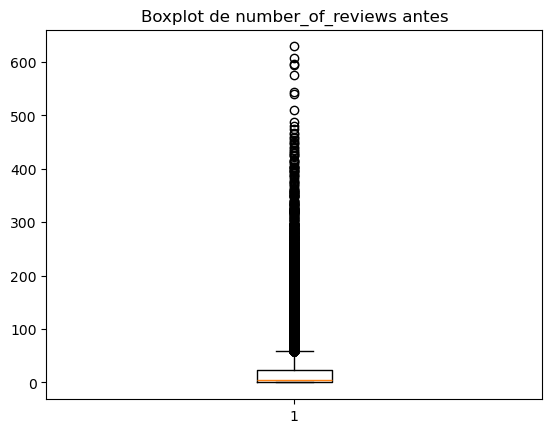

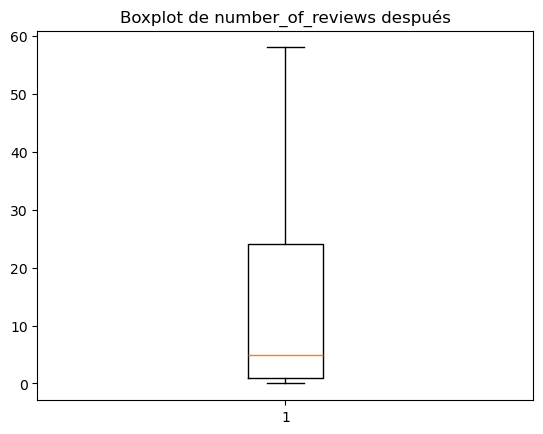

reviews_per_month -> Antes: 3285 | Después: 0


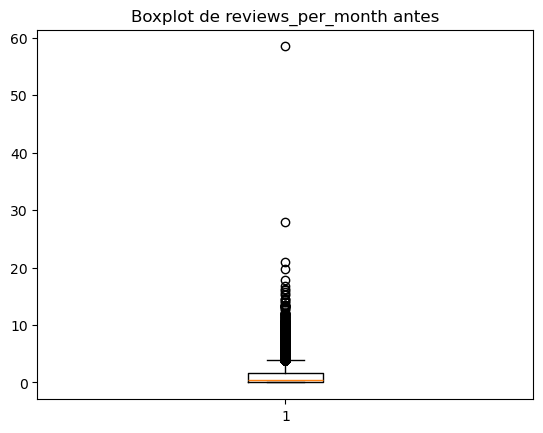

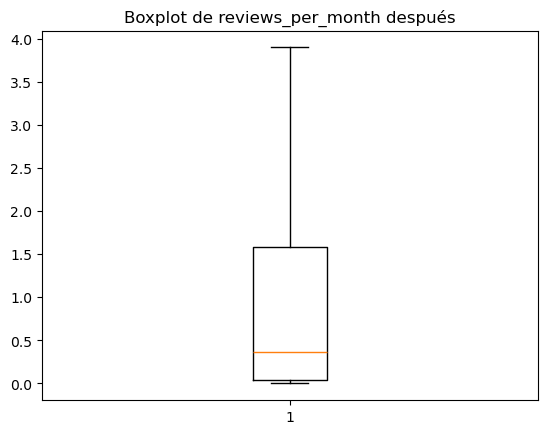

calculated_host_listings_count -> Antes: 7141 | Después: 0


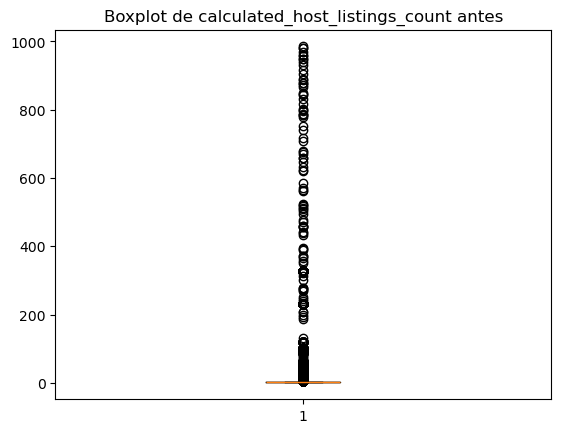

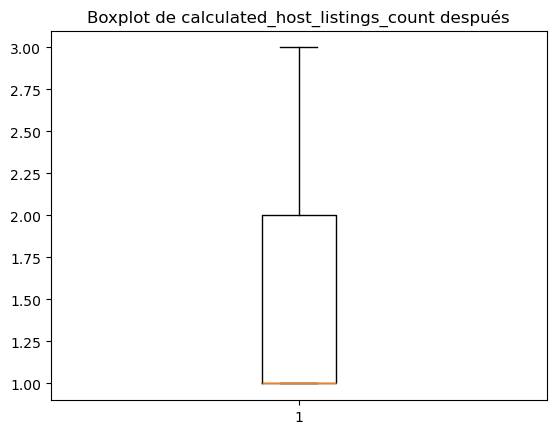

week_price -> Antes: 2965 | Después: 0


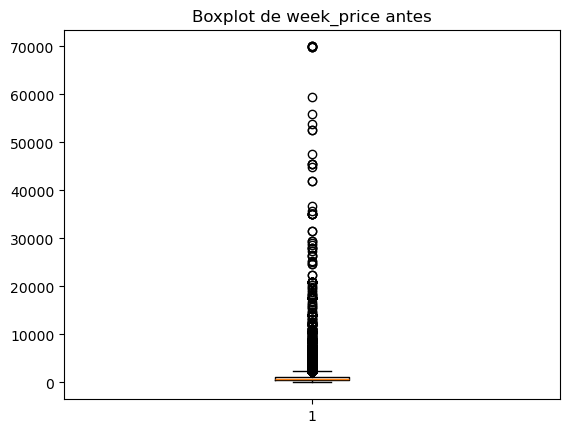

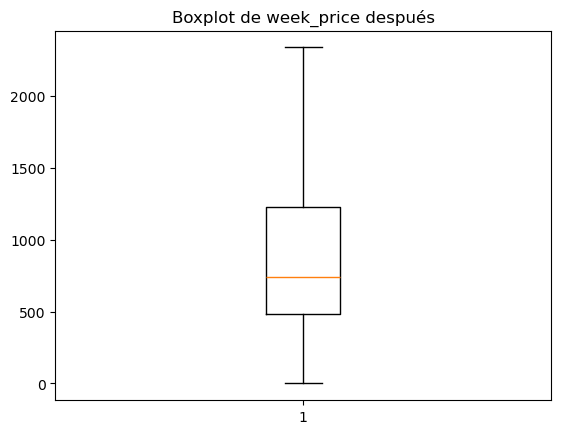

In [114]:
#Columnas numéricas. En ellas excluiremos latitud y longitud, puesto que la información que aportan son sobre localizaciones
numericas = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "week_price"]

#Vamos a representar los boxplots
for c in numericas:
    
    plt.figure()
    bp = plt.boxplot(df[c])
    
    # Antes
    outliers_ant = bp["fliers"][0].get_ydata()
    valor_min = bp["caps"][0].get_ydata()[0]
    valor_max = bp["caps"][1].get_ydata()[0]
    
    # Aplicamos filtro 
    df.loc[df[c] > valor_max, c] = valor_max
    df.loc[df[c] < valor_min, c] = valor_min
    plt.title(f"Boxplot de {c} antes")
    
    # Después
    plt.figure()
    bp = plt.boxplot(df[c])
    outliers_desp = bp["fliers"][0].get_ydata()
    
    print(f"{c} -> Antes: {len(outliers_ant)} | Después: {len(outliers_desp)}")
    
    plt.title(f"Boxplot de {c} después")
    plt.show()





# Correlación

Después de haber tratado los datos atípicos, haremos un estudio de la correlación. Como la correlación solo se puede calcular de atributos numéricos, solo lo haremos con las columnas que sean de este tipo.

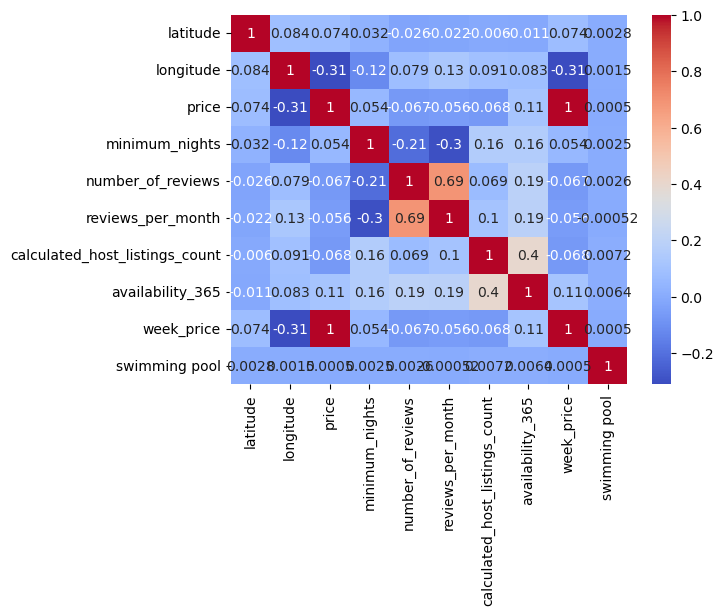

In [115]:
import seaborn as sns

#Creamos un df con solo los tipos numericos
correlacion = pd.DataFrame()
for c in df.columns:
    if df[c].dtype !="object":
        correlacion[c] = df[c]

#Correlación
matriz = correlacion.corr()
sns.heatmap(matriz, cmap="coolwarm", annot=True)
plt.show()

Podemos observar que week_price y price aportan la misma información, por tanto procedemos a eliminar una de las dos, por ejemplo week_price

In [116]:
#Eliminamos week_price
df = df.drop("week_price", axis=1)
df

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,PETS Allowed,swimming pool
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,0.21,3,365,yes,0.0
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,0.38,2,355,yes,0.0
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,0.00,1,365,no,0.0
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,58,3.90,1,194,no,0.0
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,0.10,1,0,no,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Charming one bedroom - newly renovated rowhouse,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70.0,2,0,0.00,2,9,no,0.0
48891,Affordable room in Bushwick/East Williamsburg,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40.0,4,0,0.00,2,36,yes,0.0
48892,Sunny Studio at Historical Neighborhood,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115.0,10,0,0.00,1,27,yes,1.0
48893,43rd St. Time Square-cozy single bed,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55.0,1,0,0.00,3,2,yes,0.0
